##IMPORT

In [ ]:
!pip install sentence-transformers -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 57.0 MB/s eta 0:00:00


In [ ]:
!pip install torch-geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.4 MB/s eta 0:00:00


In [ ]:
!pip install groq -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import faiss
import hdbscan
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from umap import UMAP
import json, time, re
from groq import Groq
from tqdm import tqdm
from google.colab import files, drive


##LOAD DATASET

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

# =========================
# LOAD DATA
# =========================
filepath = "/content/drive/MyDrive/Skripsi/AI_Titles_v2025.csv"

df = pd.read_csv(
    filepath,
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

data = df.head(5)

print("Jumlah data:", len(df))
print(data)


# =========================
# FUNGSI MEMBUAT TABEL
# =========================
def buat_tabel(ax, data, col_widths, wrap_widths):

    wrapped = data.copy()

    # Wrap isi setiap kolom
    for i, col in enumerate(wrapped.columns):
        wrapped[col] = wrapped[col].astype(str).apply(
            lambda x: "\n".join(
                textwrap.wrap(
                    x,
                    width=wrap_widths[i],
                    break_long_words=False,
                    break_on_hyphens=False
                )
            )
        )

    # Buat tabel memenuhi seluruh area axes
    table = ax.table(
        cellText=wrapped.values,
        colLabels=wrapped.columns,
        cellLoc="left",
        loc="center",
        colWidths=col_widths,
        bbox=[0, 0, 1, 1]
    )

    # =========================
    # FONT LEBIH BESAR
    # =========================
    table.auto_set_font_size(False)
    table.set_fontsize(14)

    # =========================
    # STYLING
    # =========================
    for (row, col), cell in table.get_celld().items():

        cell.set_edgecolor("#777777")
        cell.set_linewidth(0.7)

        # Header
        if row == 0:
            cell.set_facecolor("#D9EAF7")

            cell.set_text_props(
                weight="bold",
                color="black",
                ha="center",
                va="center",
                fontsize=14
            )

            cell.set_height(0.14)

        # Isi
        else:
            cell.set_text_props(
                ha="left",
                va="center",
                fontsize=14
            )

    # =========================
    # TINGGI BARIS
    # =========================
    for row in range(1, len(wrapped) + 1):

        max_lines = 1

        for col in range(len(wrapped.columns)):

            text = str(wrapped.iloc[row - 1, col])

            lines = text.count("\n") + 1

            max_lines = max(max_lines, lines)

        # Tinggi row
        height = min(
            0.08 + max_lines * 0.035,
            0.30
        )

        for col in range(len(wrapped.columns)):
            table[(row, col)].set_height(height)

    return table


# =========================
# BAGI KOLOM
# =========================

bagian_atas = data[
    ["Source", "Conference", "Title", "Summary"]
]

bagian_bawah = data[
    ["Authors", "Year", "Published_in", "Link", "Citations"]
]


# =========================
# CANVAS
# =========================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(20, 9)
)

axes[0].axis("off")
axes[1].axis("off")


# =========================
# TABEL ATAS
# =========================

buat_tabel(
    axes[0],
    bagian_atas,

    col_widths=[
        0.10,   # Source
        0.15,   # Conference
        0.32,   # Title
        0.43    # Summary
    ],

    wrap_widths=[
        12,
        18,
        45,
        55
    ]
)


# =========================
# TABEL BAWAH
# =========================

buat_tabel(
    axes[1],
    bagian_bawah,

    col_widths=[
        0.25,   # Authors
        0.10,   # Year
        0.18,   # Published_in
        0.37,   # Link
        0.10    # Citations
    ],

    wrap_widths=[
        30,
        10,
        18,
        45,
        10
    ]
)


# =========================
# HILANGKAN JARAK
# =========================

plt.subplots_adjust(
    top=0.99,
    bottom=0.01,
    left=0.01,
    right=0.99,
    hspace=0.02
)


# =========================
# SAVE PNG
# =========================

output_png = "/content/drive/MyDrive/Skripsi/preview_data.png"

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.close()

print("PNG berhasil disimpan:")
print(output_png)

Jumlah data: 179161
  Source Conference                                              Title  \
0  arXiv       AAAI  Supplementary material for Uncorrected least-s...   
1  arXiv       AAAI  AAAI FSS-18: Artificial Intelligence in Govern...   
2  arXiv       AAAI  AAAI-2019 Workshop on Games and Simulations fo...   
3  arXiv       AAAI  AAAI FSS-19: Artificial Intelligence in Govern...   
4  arXiv       AAAI  AAAI FSS-20: Artificial Intelligence in Govern...   

                                             Summary  \
0  Here, we provide a supplementary material for ...   
1  Proceedings of the AAAI Fall Symposium on Arti...   
2  This volume represents the accepted submission...   
3  Proceedings of the AAAI Fall Symposium on Arti...   
4  Proceedings of the AAAI Fall Symposium on Arti...   

                                             Authors    Year Published_in  \
0                                   Takayuki Osogami  2019.0        arXiv   
1              Frank Stein, Alun Preece, Mih

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179161 entries, 0 to 179160
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Source        179161 non-null  object 
 1   Conference    179161 non-null  object 
 2   Title         179161 non-null  object 
 3   Summary       135870 non-null  object 
 4   Authors       176716 non-null  object 
 5   Year          177830 non-null  float64
 6   Published_in  160918 non-null  object 
 7   Link          179161 non-null  object 
 8   Citations     179161 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 12.3+ MB


##Data Preprocessing

##Data Cleaning

In [ ]:
# Remove Duplicates
df = df.drop_duplicates(subset=["Title"])

#Remove Missing Values
df = df.dropna(subset=["Title", "Summary", "Year"])

# Remove XML / HTML tags
df["Summary"] = df["Summary"].astype(str).apply(
    lambda x: re.sub(r"<[^>]+>", "", x)
)

# Remove extra whitespace
df["Summary"] = df["Summary"].str.replace(r"\s+", " ", regex=True).str.strip()

# Jumlah data setelah cleaning
print("Jumlah data setelah cleaning:", len(df))

df.info()

Jumlah data setelah cleaning: 96038
<class 'pandas.core.frame.DataFrame'>
Index: 96038 entries, 0 to 179142
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Source        96038 non-null  object 
 1   Conference    96038 non-null  object 
 2   Title         96038 non-null  object 
 3   Summary       96038 non-null  object 
 4   Authors       95813 non-null  object 
 5   Year          96038 non-null  float64
 6   Published_in  93919 non-null  object 
 7   Link          96038 non-null  object 
 8   Citations     96038 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 7.3+ MB


##Data Filtering

In [ ]:
# Filter data tahun 2000-2025
df = df[df["Year"] >= 2000]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94643 entries, 0 to 179127
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Source        94643 non-null  object 
 1   Conference    94643 non-null  object 
 2   Title         94643 non-null  object 
 3   Summary       94643 non-null  object 
 4   Authors       94419 non-null  object 
 5   Year          94643 non-null  float64
 6   Published_in  92569 non-null  object 
 7   Link          94643 non-null  object 
 8   Citations     94643 non-null  int64  
dtypes: float64(1), int64(1), object(7)
memory usage: 7.2+ MB


##Data Transformation

In [ ]:
# Combine Title + Summary to get better semantic
df["text_input"] = (
    df["Title"] + " " + df["Summary"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94643 entries, 0 to 179127
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Source        94643 non-null  object 
 1   Conference    94643 non-null  object 
 2   Title         94643 non-null  object 
 3   Summary       94643 non-null  object 
 4   Authors       94419 non-null  object 
 5   Year          94643 non-null  float64
 6   Published_in  92569 non-null  object 
 7   Link          94643 non-null  object 
 8   Citations     94643 non-null  int64  
 9   text_input    94643 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 7.9+ MB


##Embedding

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = SentenceTransformer("allenai-specter")
model = model.to(device)

embeddings = model.encode(
    df["text_input"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding shape:", embeddings.shape)

In [ ]:
np.save("embeddings_specter.npy", embeddings)

In [ ]:
embeddings = np.load("/content/drive/MyDrive/Skripsi//embeddings_specter.npy")

print("Embedding shape:", embeddings.shape)

Embedding shape: (94643, 768)


##Dimensionality Reduction

In [ ]:
reducer = UMAP(
    n_components=64,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42,
    low_memory=True
)
reduced_embeddings = reducer.fit_transform(embeddings)

In [ ]:
np.save('reduced_embeddings.npy', reduced_embeddings.astype('float32'))
files.download('reduced_embeddings.npy')

In [ ]:
reduced_embeddings = np.load("/content/drive/MyDrive/Skripsi/reduced_embeddings.npy")

In [ ]:
print("Before:", embeddings.shape)        # (94643, 768)
print("After:", reduced_embeddings.shape)

Before: (94643, 768)
After: (94643, 64)


##Graph Construction

In [ ]:
# Normalize before FAISS (important for IndexFlatIP)
reduced = normalize(reduced_embeddings, norm='l2').astype('float32')

# Build FAISS index
k = 10
index = faiss.IndexFlatIP(reduced.shape[1])
index.add(reduced)

# Search
distances, indices = index.search(reduced, k + 1)

# Build edge list
edges_src, edges_dst, edge_weights = [], [], []
for i, (nbrs, dists) in enumerate(zip(indices, distances)):
    for j, sim in zip(nbrs[1:], dists[1:]):
        if sim > 0:
            edges_src.append(i)
            edges_dst.append(j)
            edge_weights.append(float(sim))

edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)
edge_attr = torch.tensor(edge_weights, dtype=torch.float)

print("Nodes:", len(df))
print("Edges:", edge_index.shape[1])
print("Avg edges per node:", edge_index.shape[1] / len(df))

Nodes: 94643
Edges: 946430
Avg edges per node: 10.0


##GNN Representation Learning

In [ ]:
x = torch.tensor(embeddings, dtype=torch.float)

data = Data(
    x=x,
    edge_index=edge_index,
    edge_attr=edge_attr
)

print(data)

Data(x=[94643, 768], edge_index=[2, 946430], edge_attr=[946430])


In [ ]:
torch.save(data, 'graph_data.pt')
files.download('graph_data.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = F.normalize(x, p=2, dim=1)
        return x

In [ ]:
model = GraphSAGE(
    in_dim=768,       # SPECTER embedding input
    hidden_dim=256,   # intermediate layer
    out_dim=128       # final embedding size
).to(device)

data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

In [ ]:
model.eval()
with torch.no_grad():
    gnn_embeddings = model(data.x, data.edge_index)
    gnn_embeddings = gnn_embeddings.cpu().numpy()

print("GNN embeddings shape:", gnn_embeddings.shape)

In [ ]:
# Save embeddings
np.save('gnn_embeddings.npy', gnn_embeddings.astype('float32'))
files.download('gnn_embeddings.npy')

# Save model weights in case you want to retrain or fine-tune
torch.save(model.state_dict(), 'graphsage_model.pt')
files.download('graphsage_model.pt')

print("Saved.")

In [ ]:
gnn_embeddings = np.load("/content/drive/MyDrive/Skripsi/gnn_embeddings.npy")

##Dimensionality Reduction

In [ ]:
reducer = UMAP(
    n_components=32,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

gnn_embeddings_reduced = reducer.fit_transform(gnn_embeddings)

In [ ]:
np.save('gnn_embeddings_reduced2.npy', gnn_embeddings_reduced)
files.download('gnn_embeddings_reduced2.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
gnn_embeddings_reduced = np.load("/content/drive/MyDrive/Skripsi/gnn_embeddings_reduced2.npy")

In [ ]:
print("GNN embeddings reduced shape:", gnn_embeddings_reduced.shape)

GNN embeddings reduced shape: (94643, 32)


##Clustering

In [ ]:
!pip install optuclust optuna -q

from optuclust import Optimizer
import optuna
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 27.3 MB/s eta 0:00:00


In [ ]:
def objective(trial):
    min_cluster_size = trial.suggest_int("min_cluster_size", 75, 150)
    min_samples      = trial.suggest_int("min_samples", 5, 30)

    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric='euclidean'
    )
    t    = clusterer.fit_predict(gnn_embeddings_reduced)
    mask = t != -1

    n_clusters = len(set(t)) - (1 if -1 in t else 0)
    if n_clusters < 2 or mask.sum() < 2:
        return -1.0

    idx = np.random.RandomState(42).choice(
        mask.sum(), size=min(10000, mask.sum()), replace=False
    )
    return silhouette_score(
        gnn_embeddings_reduced[mask][idx], t[mask][idx]
    )

sampler = optuna.samplers.TPESampler(seed=42)
study   = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50, show_progress_bar=True)

# Refit dengan best params
best      = study.best_params
clusterer = hdbscan.HDBSCAN(**best, metric='euclidean')
labels    = clusterer.fit_predict(gnn_embeddings_reduced)

unique, counts = np.unique(labels[labels != -1], return_counts=True)

print("Parameter terbaik :", best)
print(f"Best Silhouette   : {study.best_value:.4f}")
print(f"Topics            : {len(unique)}")
print(f"Outliers          : {round((labels == -1).sum() / len(labels) * 100, 1)}%")
print()
print("Distribusi cluster:")
bins       = [0, 100, 200, 500, 1000, counts.max()+1]
labels_bin = ['<100', '100-200', '200-500', '500-1000', '>1000']
for i in range(len(bins)-1):
    n = ((counts >= bins[i]) & (counts < bins[i+1])).sum()
    print(f"  {labels_bin[i]:>10} papers/cluster : {n} topics")

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

mask = labels != -1
X_eval = gnn_embeddings_reduced[mask]
labels_eval = labels[mask]
idx = np.random.choice(len(X_eval), size=min(10000, len(X_eval)), replace=False)

unique, counts = np.unique(labels_eval, return_counts=True)

sil = silhouette_score(X_eval[idx], labels_eval[idx])
dbi = davies_bouldin_score(X_eval, labels_eval)
ch  = calinski_harabasz_score(X_eval, labels_eval)

print("-" * 50)
print("        HASIL CLUSTERING - OPTUCLUST")
print("-" * 50)
print(f"  Parameter Terbaik   : {best}")
print(f"  Best Silhouette     : {study.best_value:.4f}")
print("-" * 50)
print(f"  Jumlah Topics       : {len(unique)}")
print(f"  Outliers            : {(labels == -1).sum()} ({round((labels == -1).sum() / len(labels) * 100, 1)}%)")
print(f"  Cluster size min    : {counts.min()}")
print(f"  Cluster size max    : {counts.max()}")
print(f"  Cluster size mean   : {counts.mean():.0f}")
print(f"  Cluster size median : {np.median(counts):.0f}")
print("-" * 50)
print(f"  Silhouette Score    : {sil:.4f}  (↑ makin baik, max 1)")
print(f"  Davies-Bouldin Index: {dbi:.4f}  (↓ makin baik, min 0)")
print(f"  Calinski-Harabasz   : {ch:.4f}  (↑ makin baik)")
print("-" * 50)

In [ ]:
import os, shutil, pandas as pd
from datetime import datetime

save_dir = "/content/drive/MyDrive/Skripsi/clustering_results"
os.makedirs(save_dir, exist_ok=True)

df['cluster'] = labels
df_clustered  = df[df['cluster'] != -1].copy()

np.save('cluster_labels.npy', labels)
df_clustered.to_csv('df_clustered.csv', index=False)

pd.DataFrame([{
    'timestamp'       : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'min_cluster_size': best['min_cluster_size'],
    'min_samples'     : best['min_samples'],
    'best_silhouette' : round(study.best_value, 4),
    'n_topics'        : len(unique),
    'outlier_pct'     : round((labels == -1).sum() / len(labels) * 100, 1)
}]).to_csv('best_params.csv', index=False)

study.trials_dataframe().to_csv('optuna_trial_history.csv', index=False)

for fname in ['cluster_labels.npy', 'df_clustered.csv',
              'best_params.csv', 'optuna_trial_history.csv']:
    shutil.copy(fname, os.path.join(save_dir, fname))
    print(f"Saved → Drive: {fname}")

Saved → Drive: cluster_labels.npy
Saved → Drive: df_clustered.csv
Saved → Drive: best_params.csv
Saved → Drive: optuna_trial_history.csv


In [ ]:
labels = np.load("/content/drive/MyDrive/Skripsi/clustering_results/cluster_labels.npy")
df_clustered = pd.read_csv("/content/drive/MyDrive/Skripsi/clustering_results/df_clustered.csv")

unique, counts = np.unique(labels[labels != -1], return_counts=True)
print("Labels shape :", labels.shape)
print("Papers       :", len(df_clustered))
print("Topics       :", len(unique))
print("Outliers     :", f"{(labels == -1).sum() / len(labels) * 100:.1f}%")

# Sample cek cluster
sample_clusters = np.random.choice(unique, size=5, replace=False)
print("=" * 60)
print("        SAMPLE CEK CLUSTER")
print("=" * 60)
for cluster_id in sample_clusters:
    mask_c = labels == cluster_id
    sample = df_clustered[df_clustered['cluster'] == cluster_id].sample(min(5, mask_c.sum()))
    print(f"\n  Cluster {cluster_id} — {mask_c.sum()} papers")
    print("  " + "-" * 55)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f"  {i}. {row['Title'][:75]}")
print("\n" + "=" * 60)

Labels shape : (94643,)
Papers       : 75703
Topics       : 250
Outliers     : 20.0%
        SAMPLE CEK CLUSTER

  Cluster 173 — 243 papers
  -------------------------------------------------------
  1. The Dislocation of Malian Territory
  2. African and Not Religious: The State of Research on Sub-Saharan Religious N
  3. BRICS Summit in Johannesburg: More Instruments and Fewer Decisions
  4. The motif of the “lost paradise” in blockbuster films set in the post-apoca
  5. Sino-Canadian documentary coproduction: transnational production mode, narr

  Cluster 164 — 264 papers
  -------------------------------------------------------
  1. Proceedings of the Doctoral Consortium and Poster Session of the 5th Intern
  2. Towards Universal Languages for Tractable Ontology Mediated Query   Answeri
  3. Answer Set Programming Modulo Theories and Reasoning about Continuous   Cha
  4. Multi Types and Reasonable Space (Long Version)
  5. Proceedings Fourth International Workshop on Linearity

  C

##Keyword Extraction

In [ ]:
# Step 1: Assign cluster labels ke dataframe
df['cluster'] = labels

# Step 2: Filter outliers
df_clustered = df[df['cluster'] != -1].copy()
print(f"Papers untuk TF-IDF: {len(df_clustered)}")

# Step 3: Gabungkan text per cluster
cluster_texts = df_clustered.groupby('cluster')['text_input'].apply(
    lambda texts: ' '.join(texts)
).reset_index()
cluster_texts.columns = ['cluster_id', 'combined_text']

print(f"Total clusters: {len(cluster_texts)}")

Papers untuk TF-IDF: 75703
Total clusters: 250


In [ ]:
# Step 4: TF-IDF per cluster
vectorizer = TfidfVectorizer(
    max_features=10000,   # vocab size
    ngram_range=(1, 2),   # unigram + bigram (misal: "neural network")
    stop_words='english',
    min_df=2,             # abaikan kata yang muncul < 2 cluster
    max_df=0.85           # abaikan kata yang muncul di > 85% cluster
)

tfidf_matrix = vectorizer.fit_transform(cluster_texts['combined_text'])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (250, 10000)


In [ ]:
# Step 5: Ekstrak top keywords per cluster
def get_top_keywords(tfidf_matrix, feature_names, cluster_idx, top_n=10):
    row = tfidf_matrix[cluster_idx].toarray().flatten()
    top_indices = row.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_indices]

# Buat dataframe keywords per cluster
cluster_keywords = []
for idx, row in cluster_texts.iterrows():
    keywords = get_top_keywords(tfidf_matrix, feature_names, idx, top_n=10)
    cluster_size = (df_clustered['cluster'] == row['cluster_id']).sum()
    cluster_keywords.append({
        'cluster_id': row['cluster_id'],
        'size': cluster_size,
        'keywords': keywords,
        'keywords_str': ', '.join(keywords)
    })

df_keywords = pd.DataFrame(cluster_keywords)
print(df_keywords.head(10).to_string())

   cluster_id  size                                                                                                                           keywords                                                                                                                     keywords_str
0           0   329                        [retinal, retinopathy, diabetic, diabetic retinopathy, glaucoma, dr, fundus, oct, screening, ophthalmology]                        retinal, retinopathy, diabetic, diabetic retinopathy, glaucoma, dr, fundus, oct, screening, ophthalmology
1           1   217                                     [dental, dentistry, caries, cbct, teeth, radiographs, oral, segmentation, diagnosis, clinical]                                     dental, dentistry, caries, cbct, teeth, radiographs, oral, segmentation, diagnosis, clinical
2           2   184                            [skin, skin cancer, melanoma, cancer, dermatology, lesion, diagnosis, lesions, clinical, deep learning]          

##Topic Labeling

In [ ]:
!pip install groq -q

from groq import Groq
import json, time, os, re, shutil
import pandas as pd
from tqdm import tqdm
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

client = Groq(api_key=GROQ_API_KEY)

In [ ]:
def get_sample_titles(cluster_id, n=5):
    mask = df_clustered['cluster'] == cluster_id
    return df_clustered[mask]['Title'].sample(
        min(n, mask.sum()), random_state=42
    ).tolist()


def extract_json(text):
    if not text or not text.strip():
        return None
    try:
        return json.loads(text.strip())
    except:
        pass
    match = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except:
            pass
    match = re.search(r'\{.*?\}', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except:
            pass
    return None


def label_topic_with_llm(cluster_id, keywords, size, sample_titles, max_retries=3):
    prompt = f"""You are a research topic expert. Given the following information about a cluster of academic papers, provide a concise topic label.

Cluster Info:
- Cluster ID: {cluster_id}
- Number of papers: {size}
- Top TF-IDF Keywords: {', '.join(keywords)}
- Sample paper titles:
{chr(10).join(f'  * {t}' for t in sample_titles)}

Respond in JSON format only, no other text:
{{
    "topic_label": "Short topic name (3-6 words)",
    "topic_description": "One sentence description",
    "confidence": "high/medium/low"
}}"""

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="llama-3.3-70b-versatile",  # gratis, cepet, pinter
                messages=[{"role": "user", "content": prompt}],
                max_tokens=200,
                temperature=0.1
            )
            raw = response.choices[0].message.content
            result = extract_json(raw)
            if result:
                return result
            time.sleep(1)

        except Exception as e:
            err = str(e).lower()
            if 'rate limit' in err or '429' in err:
                wait = (attempt + 1) * 15
                print(f"  Rate limit! Waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"  Cluster {cluster_id}: {type(e).__name__}: {e}")
                time.sleep(3)

    return {
        "topic_label": f"Topic Cluster {cluster_id}",
        "topic_description": f"Research cluster with keywords: {', '.join(keywords[:3])}",
        "confidence": "low"
    }

In [ ]:
progress_file = 'topic_labels_progress.csv'

if os.path.exists(progress_file):
    df_progress = pd.read_csv(progress_file)
    done_ids = set(df_progress['cluster_id'].tolist())
    print(f"Melanjutkan dari progress: {len(done_ids)} cluster sudah selesai")
else:
    df_progress = pd.DataFrame()
    done_ids = set()
    print("Mulai dari awal...")

results = []

for _, row in tqdm(df_keywords.iterrows(), total=len(df_keywords)):
    cluster_id = row['cluster_id']

    if cluster_id in done_ids:
        continue

    sample_titles = get_sample_titles(cluster_id, n=5)
    result = label_topic_with_llm(
        cluster_id=cluster_id,
        keywords=row['keywords'],
        size=row['size'],
        sample_titles=sample_titles
    )

    results.append({
        'cluster_id'        : cluster_id,
        'size'              : row['size'],
        'keywords'          : row['keywords_str'],
        'topic_label'       : result.get('topic_label', f'Topic Cluster {cluster_id}'),
        'topic_description' : result.get('topic_description', ''),
        'confidence'        : result.get('confidence', 'low')
    })

    time.sleep(1)

    if len(results) % 10 == 0:
        df_new = pd.DataFrame(results)
        df_progress = pd.concat([df_progress, df_new], ignore_index=True)
        df_progress.to_csv(progress_file, index=False)
        results = []
        print(f"  Checkpoint saved: {len(df_progress)} clusters done")

if results:
    df_new = pd.DataFrame(results)
    df_progress = pd.concat([df_progress, df_new], ignore_index=True)

df_topics = df_progress.copy()
df_topics.to_csv('topic_labels.csv', index=False)
print(f"\nSelesai! Total: {len(df_topics)} clusters dilabeli")

In [ ]:
df_final = df_clustered.merge(
    df_topics[['cluster_id', 'topic_label', 'topic_description', 'confidence']],
    left_on='cluster',
    right_on='cluster_id',
    how='left'
)

total     = len(df_topics)
unlabeled = df_topics['topic_label'].str.startswith('Topic Cluster').sum()
labeled   = total - unlabeled

print(f"df_final shape  : {df_final.shape}")
print(f"Total clusters  : {total}")
print(f"Labeled         : {labeled}")
print(f"Unlabeled       : {unlabeled}")
print()
print(df_final[['Title', 'cluster', 'topic_label']].head(10))

save_dir = "/content/drive/MyDrive/Skripsi/clustering_results"
os.makedirs(save_dir, exist_ok=True)

df_final.to_csv('df_final.csv', index=False)
df_topics.to_csv('topic_labels.csv', index=False)

for fname in ['df_final.csv', 'topic_labels.csv', 'topic_labels_progress.csv']:
    if os.path.exists(fname):
        shutil.copy(fname, os.path.join(save_dir, fname))
        print(f"Saved → Drive: {fname}")

In [ ]:
df_topics = pd.read_csv("/content/drive/MyDrive/Skripsi/clustering_results/topic_labels.csv")
df_final  = pd.read_csv("/content/drive/MyDrive/Skripsi/clustering_results/df_final.csv")

total     = len(df_topics)
unlabeled = df_topics['topic_label'].str.startswith('Topic Cluster').sum()
labeled   = total - unlabeled

print(f"Topics loaded   : {total}")
print(f"Labeled         : {labeled}")
print(f"Unlabeled       : {unlabeled}")

if unlabeled > 0:
    print("\nUnlabeled clusters:")
    print(df_topics[df_topics['topic_label'].str.startswith('Topic Cluster')][['cluster_id', 'keywords']])

Topics loaded   : 250
Labeled         : 250
Unlabeled       : 0


##Trend Analysis

In [ ]:
print(df_final.shape)
print(df_final.columns.tolist())
print(df_final[['Title', 'Year', 'cluster', 'topic_label']].head())

(75703, 15)
['Source', 'Conference', 'Title', 'Summary', 'Authors', 'Year', 'Published_in', 'Link', 'Citations', 'text_input', 'cluster', 'cluster_id', 'topic_label', 'topic_description', 'confidence']
                                               Title    Year  cluster  \
0  Supplementary material for Uncorrected least-s...  2019.0      222   
1  AAAI FSS-18: Artificial Intelligence in Govern...  2018.0      248   
2  AAAI-2019 Workshop on Games and Simulations fo...  2019.0       59   
3  AAAI FSS-19: Artificial Intelligence in Govern...  2019.0      248   
4  AAAI FSS-20: Artificial Intelligence in Govern...  2020.0        4   

                       topic_label  
0  Stochastic Optimization Methods  
1              AI in Public Sector  
2               Game AI and Agents  
3              AI in Public Sector  
4       Aphasia Treatment Research  


In [ ]:
print(df_final['Year'].dtype)
print(df_final['Year'].value_counts().sort_index())

float64
Year
2000.0      224
2001.0      209
2002.0      202
2003.0      223
2004.0      237
2005.0      215
2006.0      249
2007.0      225
2008.0      232
2009.0      279
2010.0      332
2011.0      389
2012.0      519
2013.0      582
2014.0      720
2015.0      899
2016.0     1380
2017.0     1859
2018.0     3478
2019.0     5706
2020.0     6216
2021.0     7735
2022.0     8181
2023.0    11780
2024.0    14453
2025.0     9179
Name: count, dtype: int64


In [ ]:
# Fix Year dtype
df_final['Year'] = df_final['Year'].astype(int)

# Filter tahun yang relevan (2015-2024, exclude 2025 karena belum lengkap)
df_trend = df_final[
    (df_final['Year'] >= 2000) &
    (df_final['Year'] <= 2025)
].copy()

print(f"Papers untuk trend analysis: {len(df_trend)}")
print(f"Year range: {df_trend['Year'].min()} - {df_trend['Year'].max()}")

Papers untuk trend analysis: 75703
Year range: 2000 - 2025


In [ ]:
# 1. Topic Volume per Year
topic_year = df_trend.groupby(['Year', 'topic_label']).size().reset_index(name='count')
topic_pivot = topic_year.pivot(index='Year', columns='topic_label', values='count').fillna(0)

print(f"Shape: {topic_pivot.shape}")

Shape: (26, 242)


In [ ]:
# 2. Top 10 Topics Overall (2000-2025)
top_topics = df_trend['topic_label'].value_counts().head(10)
print("\nTop 10 Topics:")


Top 10 Topics:


In [ ]:
# 3. Emerging Topics — tumbuh paling pesat (2020 vs 2025)
early = topic_pivot.loc[2020] if 2020 in topic_pivot.index else None
recent = topic_pivot.loc[2024] if 2025 in topic_pivot.index else None

if early is not None and recent is not None:
    growth = ((recent - early) / (early + 1) * 100).sort_values(ascending=False)

    print("\nTop 10 Emerging Topics (growth 2020→2025):")
    print(growth.head(10))

    print("\nTop 10 Declining Topics (2020→2025):")
    print(growth.tail(10))


Top 10 Emerging Topics (growth 2020→2025):
topic_label
AI Generated Image Detection          2350.000000
Clinical NLP and LLMs                 2120.000000
AI Generated Text Detection           1400.000000
Reasoning in Large Language Models    1350.000000
AI in Academic Writing                1300.000000
Large Language Models                 1018.181818
AI Risk Governance                     925.000000
Supply Chain Management                896.774194
Weather Forecasting Models             877.777778
AI in Farming Management               833.333333
dtype: float64

Top 10 Declining Topics (2020→2025):
topic_label
Medical and Veterinary Research       -63.636364
Generative Adversarial Networks       -66.666667
Zero Shot Learning                    -66.666667
Semantic Word Representations         -66.666667
Avian Disease Outbreaks               -68.888889
Global Health Disparities             -71.428571
Variational Autoencoders              -75.000000
Anterior Cruciate Ligament Injuries 

In [ ]:
# 4. Simpan untuk visualisasi
topic_year.to_csv('topic_trend.csv', index=False)
topic_pivot.to_csv('topic_pivot.csv')

files.download('topic_trend.csv')
files.download('topic_pivot.csv')
print("Trend data saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Trend data saved!


##Visualization

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFont

np.random.seed(42)

fig, axs = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Overview of Topic Clustering Data", fontsize=14, fontweight='bold', y=0.995)

# ============================================================
# 1. UMAP Scatter — GANTI dengan gnn_embeddings_reduced2.npy + cluster_labels.npy
# ============================================================
# GANTI baris di bawah ini dengan data asli:
# reduced = np.load("gnn_embeddings_reduced2.npy")   # shape (N, 32) -> ambil 2 kolom pertama, atau UMAP ulang ke 2D
# labels  = np.load("cluster_labels.npy")

n_clusters = 6
cluster_names = ["AI in Education", "AI in Healthcare", "Generative AI Creativity",
                  "AI in Marketing", "Cognitive AI", "Speech Recognition"]
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cx, cy = np.random.uniform(-8, 8, 2)
    n_pts = np.random.randint(60, 150)
    x = cx + np.random.randn(n_pts) * 0.8
    y = cy + np.random.randn(n_pts) * 0.8
    axs[0, 0].scatter(x, y, s=10, color=colors[i], alpha=0.6, label=cluster_names[i])

noise_x = np.random.uniform(-10, 10, 40)
noise_y = np.random.uniform(-10, 10, 40)
axs[0, 0].scatter(noise_x, noise_y, s=8, color='lightgray', alpha=0.5, label='Noise (-1)')

axs[0, 0].set_title("UMAP Projection of GNN Embeddings", fontsize=10)
axs[0, 0].set_xlabel("UMAP-1")
axs[0, 0].set_ylabel("UMAP-2")
axs[0, 0].legend(fontsize=6, loc='upper right', framealpha=0.8)

# ============================================================
# 2. Distribusi jumlah paper per tahun — GANTI dengan df_final['Year'].value_counts()
# ============================================================
# GANTI baris di bawah dengan data asli:
# year_counts = df_final['Year'].value_counts().sort_index()
# years, counts = year_counts.index, year_counts.values

years = np.arange(2000, 2026)
base = np.piecewise(
    years.astype(float),
    [years < 2010, (years >= 2010) & (years < 2020), years >= 2020],
    [lambda y: 800 + (y - 2000) * 50,
     lambda y: 1300 + (y - 2010) * 150,
     lambda y: 2800 + (y - 2020) * 900]
)
counts = base + np.random.normal(0, 100, len(years))
counts = np.clip(counts, 0, None)

axs[0, 1].bar(years, counts, color='#4C72B0')
axs[0, 1].set_title("Number of Papers per Year", fontsize=10)
axs[0, 1].set_xlabel("Year")
axs[0, 1].set_ylabel("Number of Papers")
axs[0, 1].tick_params(axis='x', rotation=45)

# ============================================================
# 3. Word cloud — GANTI dengan keywords dari df_keywords (1 cluster pilihan)
# ============================================================
# GANTI dict di bawah dengan data asli, misal:
# row = df_keywords[df_keywords['cluster_id'] == TARGET_CLUSTER_ID].iloc[0]
# words = dict(zip(row['keywords'], range(len(row['keywords']), 0, -1)))

words = {
    "learning": 40, "education": 36, "student": 28, "tutoring": 24,
    "personalized": 22, "assessment": 18, "classroom": 16, "adaptive": 15,
    "intelligent": 14, "curriculum": 12, "engagement": 10, "feedback": 9,
    "e-learning": 8, "pedagogy": 7,
}
axs[1, 0].axis('off')
axs[1, 0].set_title("Top Keywords Word Cloud", fontsize=10)

rng = np.random.RandomState(7)
placed = []
max_w = max(words.values())
for word, weight in words.items():
    for attempt in range(50):
        x, y = rng.uniform(0.05, 0.95), rng.uniform(0.1, 0.9)
        if all((x - px) ** 2 + (y - py) ** 2 > 0.02 for px, py in placed):
            placed.append((x, y))
            break
    fontsize = 8 + weight * 0.9
    color = plt.cm.viridis(weight / max_w)
    axs[1, 0].text(x, y, word, fontsize=fontsize, color=color,
                    ha='center', va='center', fontweight='bold',
                    transform=axs[1, 0].transAxes)
axs[1, 0].set_xlim(0, 1)
axs[1, 0].set_ylim(0, 1)

# ============================================================
# 4. Bar chart top keywords (TF-IDF) — pakai dict `words` yang sama
# ============================================================
kw_labels = list(words.keys())[:10][::-1]
kw_values = [words[k] for k in kw_labels]
colors_bar = plt.cm.Blues(np.linspace(0.4, 0.85, len(kw_labels)))
axs[1, 1].barh(kw_labels, kw_values, color=colors_bar, edgecolor='white')
axs[1, 1].set_title("Top TF-IDF Keywords", fontsize=10)
axs[1, 1].set_xlabel("TF-IDF Weight")
for s in ['top', 'right', 'left']:
    axs[1, 1].spines[s].set_visible(False)
axs[1, 1].tick_params(left=False)

plt.tight_layout()
plt.savefig("fig_topic_data.png", dpi=300, bbox_inches='tight')
plt.close()

# ============================================================
# 5. Tambah caption di bawah gambar (format seperti Fig. 2 referensi)
# ============================================================
img = Image.open("fig_topic_data.png")
w, h = img.size
caption_h = 110
new_img = Image.new('RGB', (w, h + caption_h), 'white')
new_img.paste(img, (0, 0))

draw = ImageDraw.Draw(new_img)
caption = "Fig. X. Illustration of topic clustering data: UMAP projection of GNN\nembeddings, publication trend, and representative keywords per topic."
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf", 28)
except:
    font = ImageFont.load_default()

lines = caption.split("\n")
y_text = h + 20
for line in lines:
    bbox = draw.textbbox((0, 0), line, font=font)
    tw = bbox[2] - bbox[0]
    draw.text(((w - tw) / 2, y_text), line, fill='black', font=font)
    y_text += 38

new_img.save("fig_topic_data_with_caption.png", dpi=(300, 300))

from google.colab import files
files.download("fig_topic_data_with_caption.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

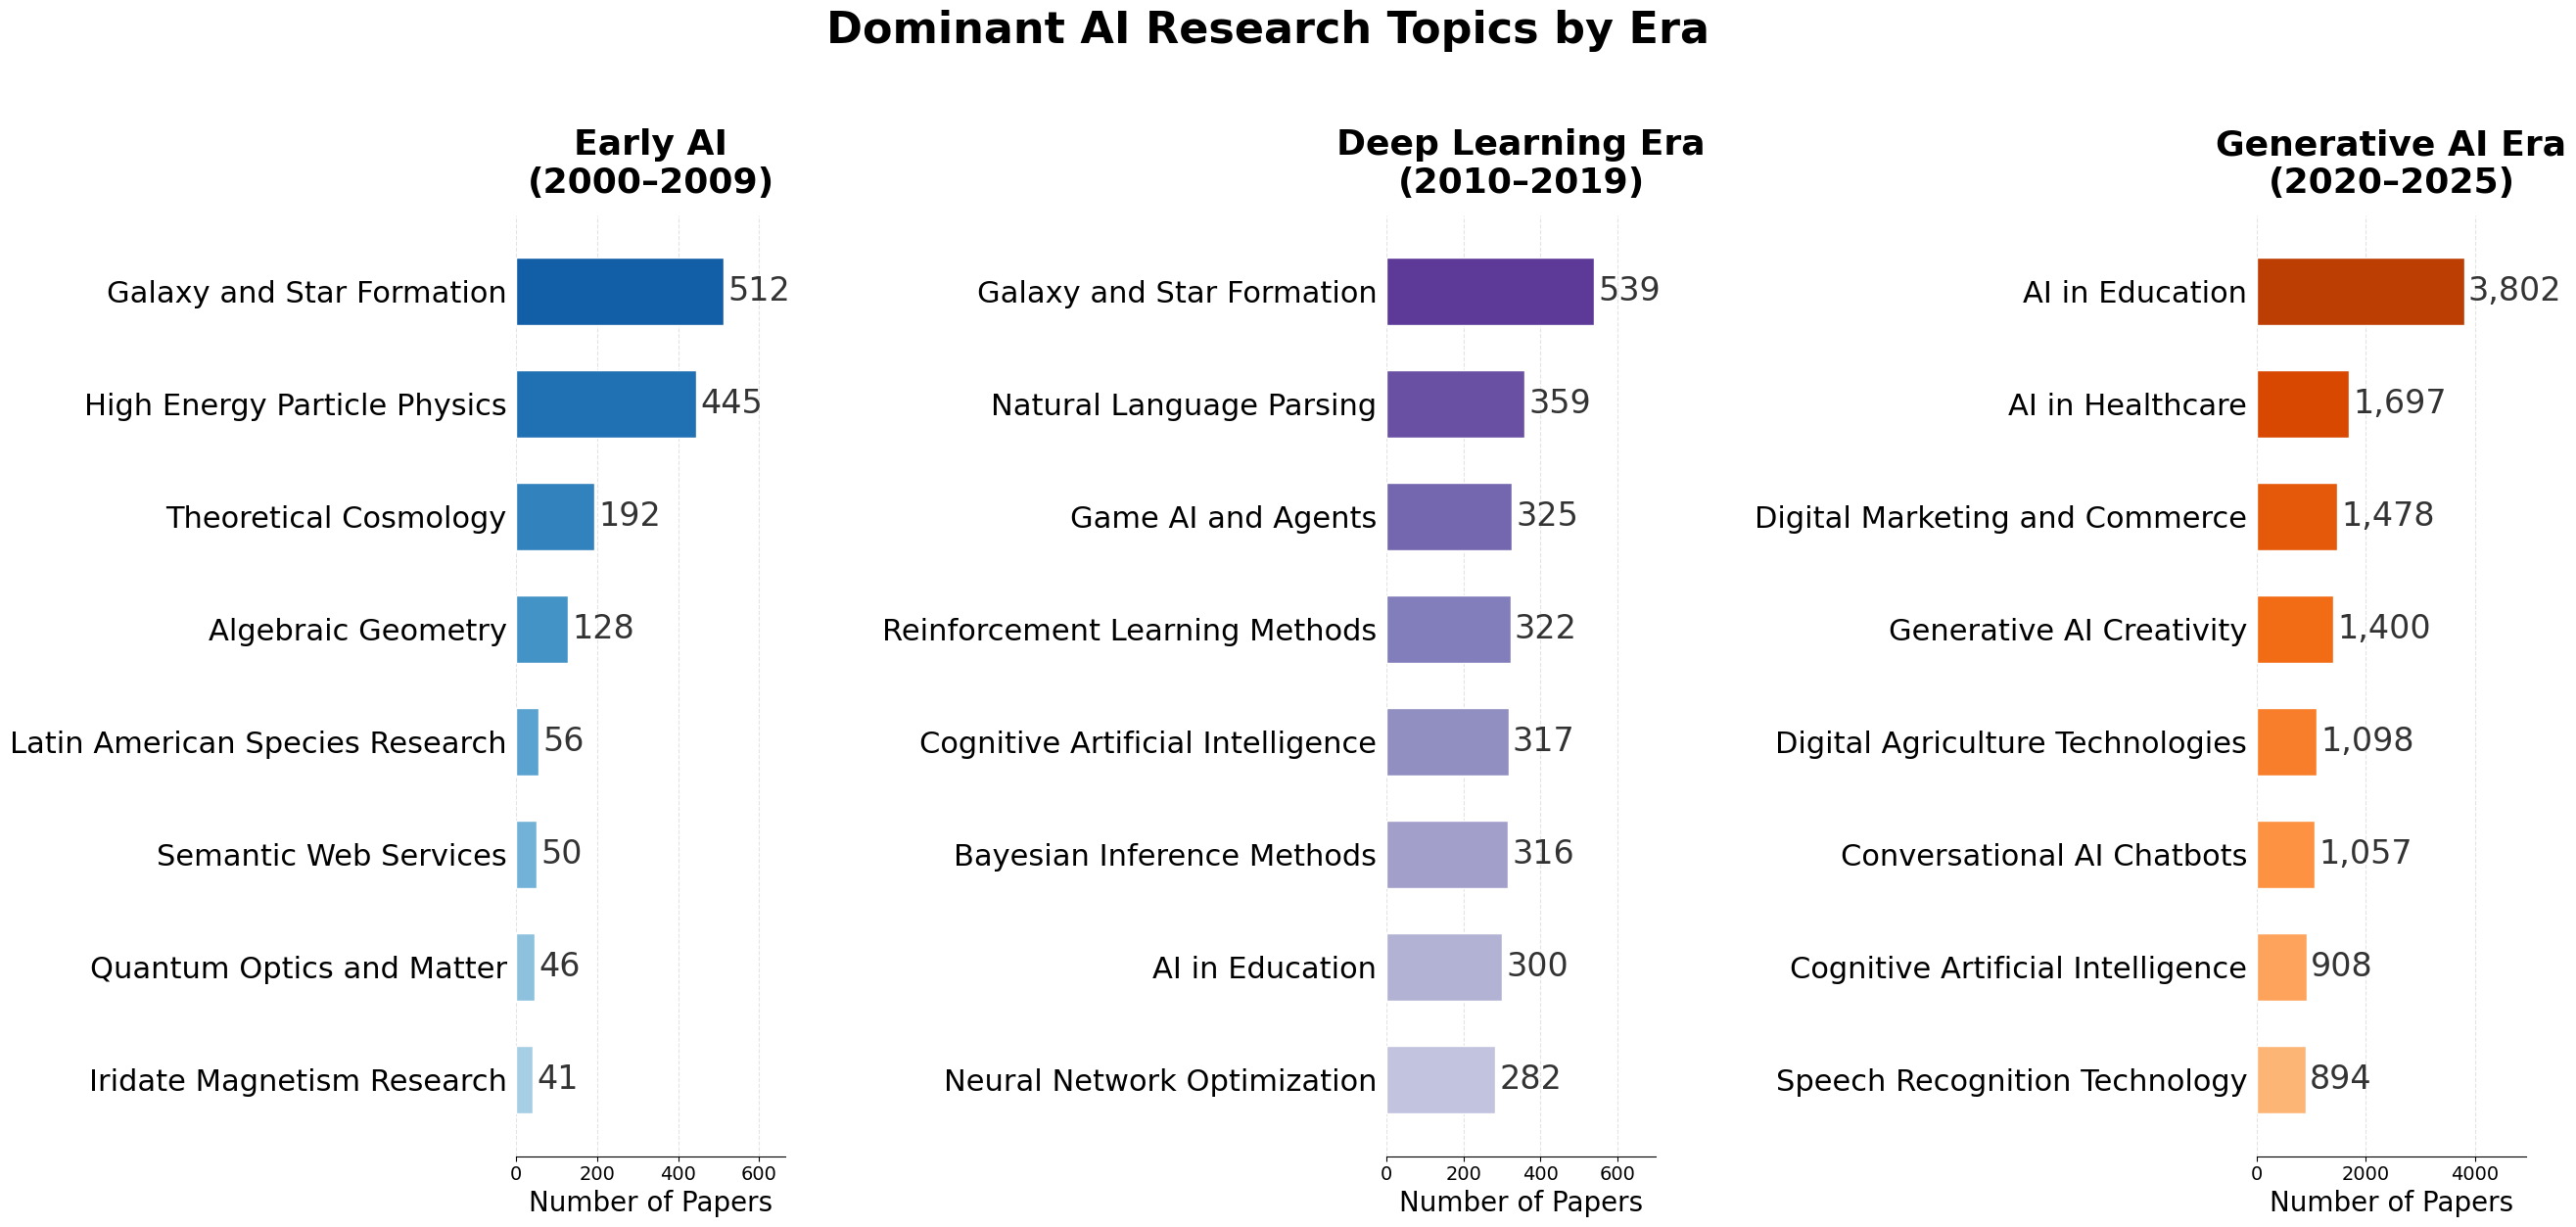

Saved: dominant_topics_per_era.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Definisi era ─────────────────────────────────────────────────────────────
eras = {
    'Early AI\n(2000–2009)': (2000, 2009),
    'Deep Learning Era\n(2010–2019)': (2010, 2019),
    'Generative AI Era\n(2020–2025)': (2020, 2025),
}

era_colors = {
    'Early AI\n(2000–2009)': plt.cm.Blues,
    'Deep Learning Era\n(2010–2019)': plt.cm.Purples,
    'Generative AI Era\n(2020–2025)': plt.cm.Oranges,
}

TOP_N = 8

# ── Hitung dominant topics per era ───────────────────────────────────────────
era_data = {}

for era_name, (y_start, y_end) in eras.items():
    mask = (df_trend['Year'] >= y_start) & (df_trend['Year'] <= y_end)
    top = (
        df_trend[mask]['topic_label']
        .value_counts()
        .head(TOP_N)
        .sort_values()
    )
    era_data[era_name] = top

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(26, 12))

fig.suptitle(
    'Dominant AI Research Topics by Era',
    fontsize=32,
    fontweight='bold',
    y=1.04
)

for ax, (era_name, top) in zip(axes, era_data.items()):

    cmap = era_colors[era_name]
    colors = cmap(np.linspace(0.35, 0.82, len(top)))

    bars = ax.barh(
        top.index,
        top.values,
        color=colors,
        edgecolor='white',
        height=0.6
    )

    # Nilai di ujung bar (angka tidak bold, ukuran sama dgn label topic)
    for bar, val in zip(bars, top.values):
        ax.text(
            val + top.values.max() * 0.02,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}',
            va='center',
            ha='left',
            fontsize=24,
            fontweight='normal',
            color='#333333'
        )

    ax.set_title(
        era_name,
        fontsize=26,
        fontweight='bold',
        pad=16
    )

    ax.set_xlabel(
        'Number of Papers',
        fontsize=20
    )

    # kasih ruang ekstra biar angka ga mepet/kepotong
    ax.set_xlim(0, top.values.max()*1.3)

    # Hilangkan border
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Tick
    ax.tick_params(axis='y', left=False)
    ax.tick_params(axis='x', labelsize=14)

    # Label topic (ukuran disamakan dgn angka, tidak bold)
    for label in ax.get_yticklabels():
        label.set_fontsize(22)
        label.set_fontweight('normal')

    # Grid
    ax.xaxis.grid(True, linestyle='--', alpha=0.35)
    ax.set_axisbelow(True)

plt.tight_layout(w_pad=6)

plt.savefig(
    'dominant_topics_per_era.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Saved: dominant_topics_per_era.png")

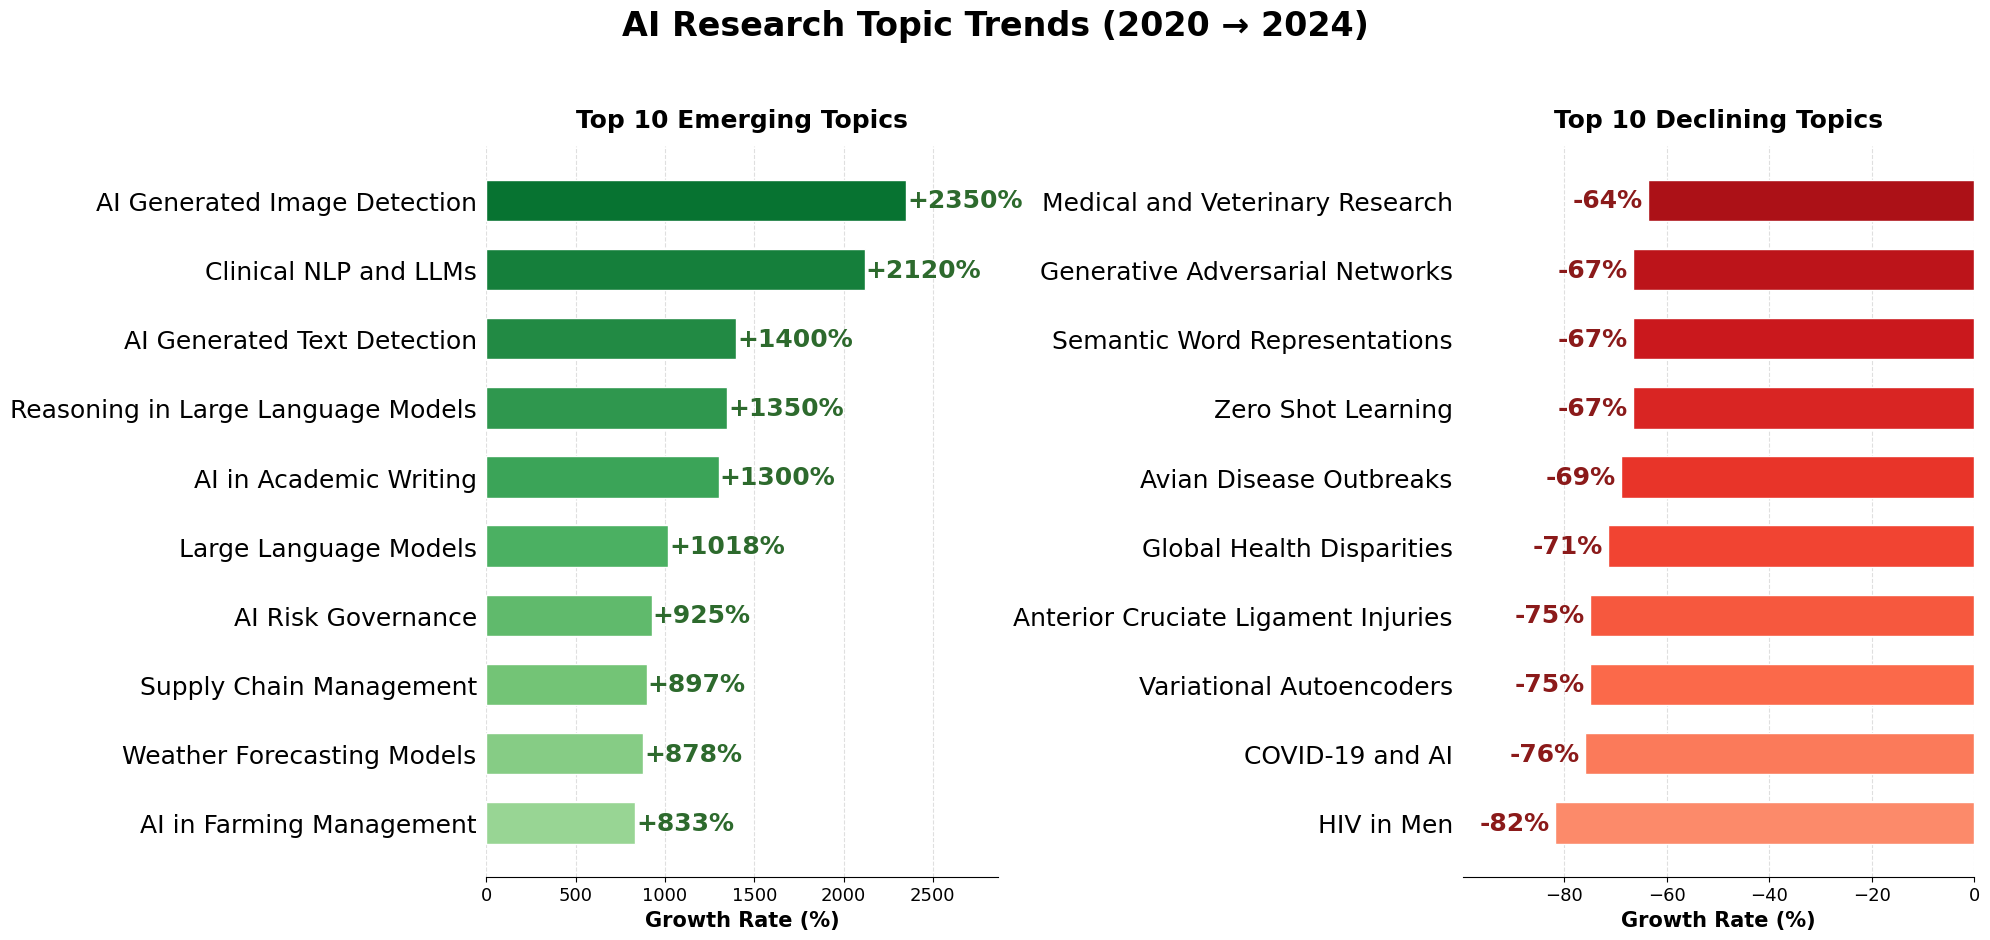

Saved: emerging_declining_topics.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Font default
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Fix kondisi ──────────────────────────────────────────────────────────────
early = topic_pivot.loc[2020] if 2020 in topic_pivot.index else None
recent = topic_pivot.loc[2024] if 2024 in topic_pivot.index else None

if early is None or recent is None:
    print("Data 2020 atau 2024 tidak ditemukan!")
else:
    growth = ((recent - early) / (early + 1) * 100).sort_values(ascending=False)

    emerging = growth.head(10).sort_values()
    declining = growth.tail(10).sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    fig.suptitle(
        'AI Research Topic Trends (2020 → 2024)',
        fontsize=24,
        fontweight='bold',
        y=1.04
    )

    # ===================== Emerging =====================
    colors_up = plt.cm.Greens(np.linspace(0.4, 0.85, len(emerging)))

    bars1 = axes[0].barh(
        emerging.index,
        emerging.values,
        color=colors_up,
        edgecolor='white',
        height=0.6
    )

    for bar, val in zip(bars1, emerging.values):
        axes[0].text(
            val + 5,
            bar.get_y() + bar.get_height()/2,
            f'+{val:.0f}%',
            va='center',
            ha='left',
            fontsize=18,
            fontweight='bold',
            color='#2d6a2d'
        )

    axes[0].set_title(
        'Top 10 Emerging Topics',
        fontsize=18,
        fontweight='bold',
        pad=14
    )

    axes[0].set_xlabel(
        'Growth Rate (%)',
        fontsize=15,
        fontweight='bold'
    )

    axes[0].set_xlim(0, emerging.max() * 1.22)

    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].spines['left'].set_visible(False)

    axes[0].tick_params(left=False, labelsize=13)

    axes[0].xaxis.grid(True, linestyle='--', alpha=0.4)
    axes[0].set_axisbelow(True)

    # Nama topik kiri (ukuran disamakan dgn angka, tidak bold)
    for label in axes[0].get_yticklabels():
        label.set_fontsize(18)
        label.set_fontweight('normal')

    # ===================== Declining =====================
    colors_dn = plt.cm.Reds(np.linspace(0.4, 0.85, len(declining)))

    bars2 = axes[1].barh(
        declining.index,
        declining.values,
        color=colors_dn,
        edgecolor='white',
        height=0.6
    )

    for bar, val in zip(bars2, declining.values):
        axes[1].text(
            val - 1,
            bar.get_y() + bar.get_height()/2,
            f'{val:.0f}%',
            va='center',
            ha='right',
            fontsize=18,
            fontweight='bold',
            color='#8b1a1a'
        )

    axes[1].set_title(
        'Top 10 Declining Topics',
        fontsize=18,
        fontweight='bold',
        pad=14
    )

    axes[1].set_xlabel(
        'Growth Rate (%)',
        fontsize=15,
        fontweight='bold'
    )

    axes[1].set_xlim(declining.min() * 1.22, 0)

    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
    axes[1].spines['left'].set_visible(False)

    axes[1].tick_params(left=False, labelsize=13)

    axes[1].xaxis.grid(True, linestyle='--', alpha=0.4)
    axes[1].set_axisbelow(True)

    # Nama topik kanan (ukuran disamakan dgn angka, tidak bold)
    for label in axes[1].get_yticklabels():
        label.set_fontsize(18)
        label.set_fontweight('normal')

    plt.tight_layout()

    plt.savefig(
        "emerging_declining_topics.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved: emerging_declining_topics.png")

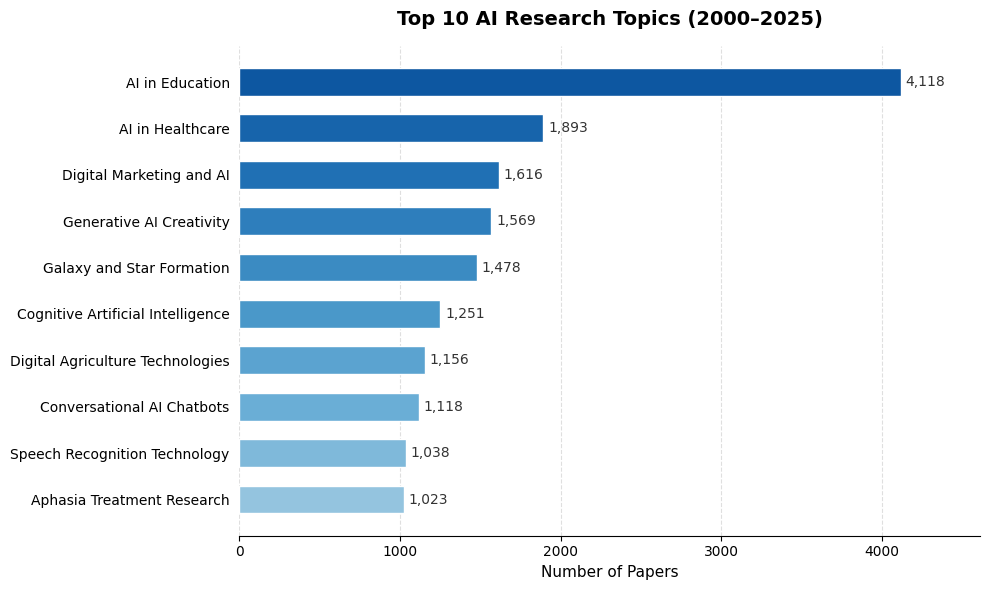

Saved: top10_topics.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

top_topics = df_trend['topic_label'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.Blues(np.linspace(0.4, 0.85, len(top_topics)))
bars = ax.barh(top_topics.index, top_topics.values, color=colors, edgecolor='white', height=0.6)

# Label angka di ujung bar (digedein)
for bar, val in zip(bars, top_topics.values):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', ha='left', fontsize=14, fontweight='bold', color='#333333')

ax.set_xlabel('Number of Papers', fontsize=11)
ax.set_title('Top 10 AI Research Topics (2000–2025)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, top_topics.values.max() * 1.12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Nama topik di sumbu-y (digedein)
for label in

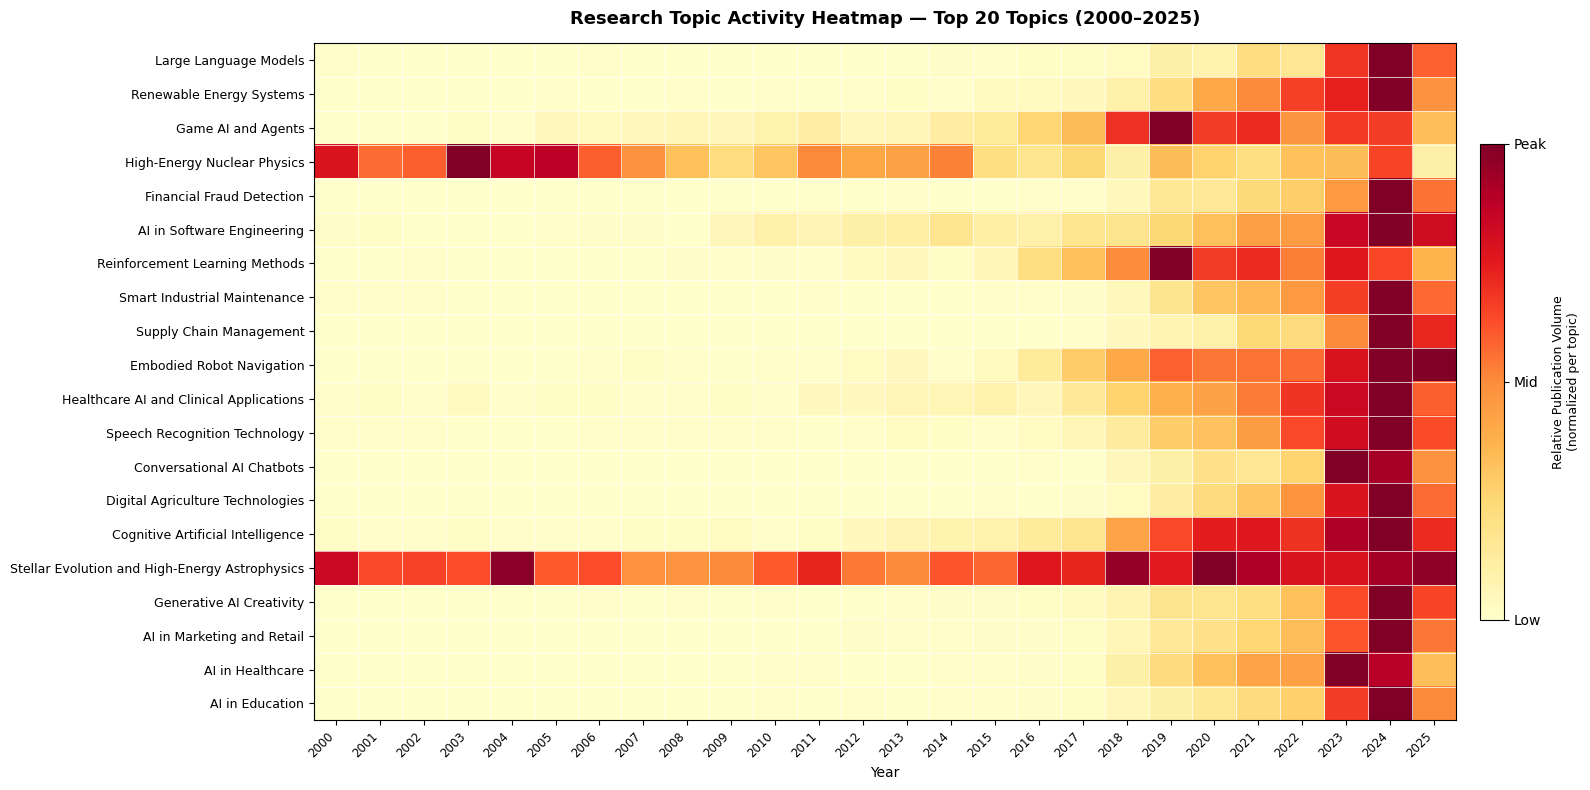

Saved: heatmap_topics.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ── Parameter ─────────────────────────────────────────────────────────────────
TOP_N    = 20
YEAR_MIN = 2000
YEAR_MAX = 2025

# ── Ambil top N topik berdasarkan total volume ─────────────────────────────────
top_topic_names = (
    df_trend['topic_label']
    .value_counts()
    .head(TOP_N)
    .index.tolist()
)

# ── Filter dan pivot ───────────────────────────────────────────────────────────
df_heat = df_trend[
    (df_trend['topic_label'].isin(top_topic_names)) &
    (df_trend['Year'] >= YEAR_MIN) &
    (df_trend['Year'] <= YEAR_MAX)
]

heat_pivot = (
    df_heat
    .groupby(['topic_label', 'Year'])
    .size()
    .unstack(fill_value=0)
)

# Pastikan semua tahun ada meski 0
all_years = list(range(YEAR_MIN, YEAR_MAX + 1))
heat_pivot = heat_pivot.reindex(columns=all_years, fill_value=0)

# Urutkan topik berdasarkan total (terbesar di atas)
heat_pivot = heat_pivot.loc[
    heat_pivot.sum(axis=1).sort_values(ascending=True).index
]

# ── Normalisasi per-baris (0–1) biar perbedaan tren keliatan) ─────────────────
heat_norm = heat_pivot.div(heat_pivot.max(axis=1), axis=0).fillna(0)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(
    heat_norm.values,
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest',
    vmin=0, vmax=1
)

# Axes labels
ax.set_xticks(range(len(all_years)))
ax.set_xticklabels(all_years, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(heat_pivot)))
ax.set_yticklabels(heat_pivot.index, fontsize=9)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Relative Publication Volume\n(normalized per topic)', fontsize=9)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Low', 'Mid', 'Peak'])

# Grid tipis antar sel
ax.set_xticks(np.arange(-0.5, len(all_years), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat_pivot), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=0.5)
ax.tick_params(which='minor', bottom=False, left=False)

ax.set_title(
    f'Research Topic Activity Heatmap — Top {TOP_N} Topics (2000–2025)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlabel('Year', fontsize=10)

plt.tight_layout()
plt.savefig('heatmap_topics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: heatmap_topics.png")

In [ ]:
from google.colab import files

files.download('dominant_topics_per_era.png')
files.download('emerging_declining_topics.png')
files.download('top10_topics.png')
files.download('heatmap_topics.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>